In [1]:
import os
import time

import netCDF4 as nc4

os.environ["TZ"] = "UTC"
time.tzset()

import datetime

from icecream import ic

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import matplotlib.dates as mdates

import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from mpl_toolkits.basemap import Basemap
import cartopy.feature as cf

import numpy as np

import matplotlib.cm as mplcm
import matplotlib.colors as colors

from data_tools import dict_extracted_data, dict_extracted_data_2018, dict_extracted_data_2021, load_sic
from data_tools import generate_lists_data, instrument_label, ColormapMapper

import time

import xarray as xr

/home/jrmet/Desktop/Git/periodic_oscillation_wave_damping_2021_svalbard_waves_in_ice_arven_etter_nansen/cleaned_notebooks/drifters_data/data_tools.py:70: UserWarning: Warning: converting a masked element to nan.
  crrt_dict_wave["swh"] = float(array_swh[crrt_index])
/home/jrmet/Desktop/Git/periodic_oscillation_wave_damping_2021_svalbard_waves_in_ice_arven_etter_nansen/cleaned_notebooks/drifters_data/data_tools.py:73: UserWarning: Warning: converting a masked element to nan.
  crrt_dict_wave["tz0"] = float(array_tz0[crrt_index])


In [2]:
ic.configureOutput(prefix="", outputFunction=print)

In [3]:
ic(dict_extracted_data_2018.keys())
ic(dict_extracted_data_2018["13319"].keys())
ic(list(dict_extracted_data_2018["13319"]["time_pos"].keys())[0])
ic(dict_extracted_data_2018["13319"]["time_pos"][datetime.datetime(2021, 3, 28, 18, 3, 25)])  # this contains a tuple (lat, lon)
ic(list(dict_extracted_data_2018["13319"]["time_wave"].keys())[0])
ic(dict_extracted_data_2018["13319"]["time_wave"][datetime.datetime(2021, 3, 26, 13, 54, 29)])  # this contains a dict with the wave information

ic(dict_extracted_data_2021.keys())
ic(dict_extracted_data_2021["19648"].keys())
ic(list(dict_extracted_data_2021["19648"]["time_pos"].keys())[0])
ic(dict_extracted_data_2021["19648"]["time_pos"][datetime.datetime(2021, 2, 25, 3, 0, 5)])  # this contains a tuple (lat, lon)
ic(list(dict_extracted_data_2021["19648"]["time_wave"].keys())[0])
ic(dict_extracted_data_2021["19648"]["time_wave"][datetime.datetime(2021, 2, 25, 4, 1, 58)])  # this contains a dict with the wave information

dict_extracted_data_2018.keys(): dict_keys(['200913', '13319', '200906', '200905', '200911', '200910'])
dict_extracted_data_2018["13319"].keys(): dict_keys(['time_pos', 'time_wave'])
list(dict_extracted_data_2018["13319"]["time_pos"].keys())[0]: datetime.datetime(2021, 3, 28, 18, 3, 25)
dict_extracted_data_2018["13319"]["time_pos"][datetime.datetime(2021, 3, 28, 18, 3, 25)]: (76.26742553710938, 21.01177215576172)
list(dict_extracted_data_2018["13319"]["time_wave"].keys())[0]: datetime.datetime(2021, 3, 26, 13, 54, 29)
dict_extracted_data_2018["13319"]["time_wave"][datetime.datetime(2021, 3, 26, 13, 54, 29)]: {'frequencies': masked_array(data=[0.05      , 0.05346798, 0.05717649, 0.06114223,
                                                                                                               0.06538302, 0.06991796, 0.07476744, 0.07995328,
                                                                                                               0.08549879, 0.09142896, 0.09777

{'spectrum': array([1.6144882e-03, 8.8890130e-04, 9.1377745e-04, 1.0815959e-03,
        2.9586058e-03, 5.1755849e-03, 6.7298515e-03, 9.9394722e-03,
        2.6532728e-03, 4.5246147e-03, 2.5123372e-03, 3.5814103e-04,
        1.2078426e-04, 4.4790497e-05, 4.2973410e-05, 2.2956123e-05,
        2.8194707e-05, 1.6140402e-05, 1.8517670e-05, 1.1673761e-05,
        1.3871410e-05, 1.3176331e-05, 1.4443126e-05, 7.7699915e-06,
        4.3772757e-06, 1.9122929e-06, 3.5060414e-06, 2.9593857e-06,
        2.6201074e-06, 4.4120275e-06, 6.4197734e-06, 2.5014442e-06,
        2.2378133e-06, 2.9210571e-06, 3.2214678e-06, 1.6630664e-06,
        2.4365481e-06, 2.0949537e-06, 2.2180036e-06, 1.3667955e-06,
        8.8483722e-07, 8.7386911e-07, 1.0309994e-06, 9.1283181e-07,
        1.3094385e-06, 1.2257113e-06, 1.0524526e-06, 1.3389772e-06,
        8.4303082e-07, 4.8174456e-07, 2.6464997e-07, 2.9847791e-07,
        5.3125939e-07, 5.0526523e-07, 6.5142990e-07], dtype=float32),
 'swh': nan,
 'hs': 0.055168375372

In [7]:
print("***** configure matplotlib")
plt.rcParams.update({'font.size': 12})
list_colors = list(mcolors.TABLEAU_COLORS)
list_colors.append("k")

NUM_COLORS = 20

cm = plt.get_cmap('gist_rainbow')
cNorm = colors.Normalize(vmin=0, vmax=NUM_COLORS - 1)
scalarMap = mplcm.ScalarMappable(norm=cNorm, cmap=cm)

***** configure matplotlib


In [5]:
event_1_start = datetime.datetime(2021, 3, 1, 0, 0, 0)
event_1__stop = datetime.datetime(2021, 3, 3, 23, 59, 59)

# all the instruments around
event_1_list_instruments_neighborhood = [
    '200913',
    '13319',
    '200905',
    '19612',
    '19631',
    '19633',
    '19636',
    '19643',
    '19648',
]

list_most_relevant_instruments = [
    "19648",
    "200905",
    "13319",
]

dict_lists_data = generate_lists_data(
    dict_extracted_data,
    event_1_list_instruments_neighborhood,
    event_1_start,
    event_1__stop
)

dict_lists_data_relevant = generate_lists_data(
    dict_extracted_data,
    list_most_relevant_instruments,
    event_1_start,
    event_1__stop
)

dict_lists_data_all = generate_lists_data(
    dict_extracted_data,
    list(dict_extracted_data),
    event_1_start,
    event_1__stop
)

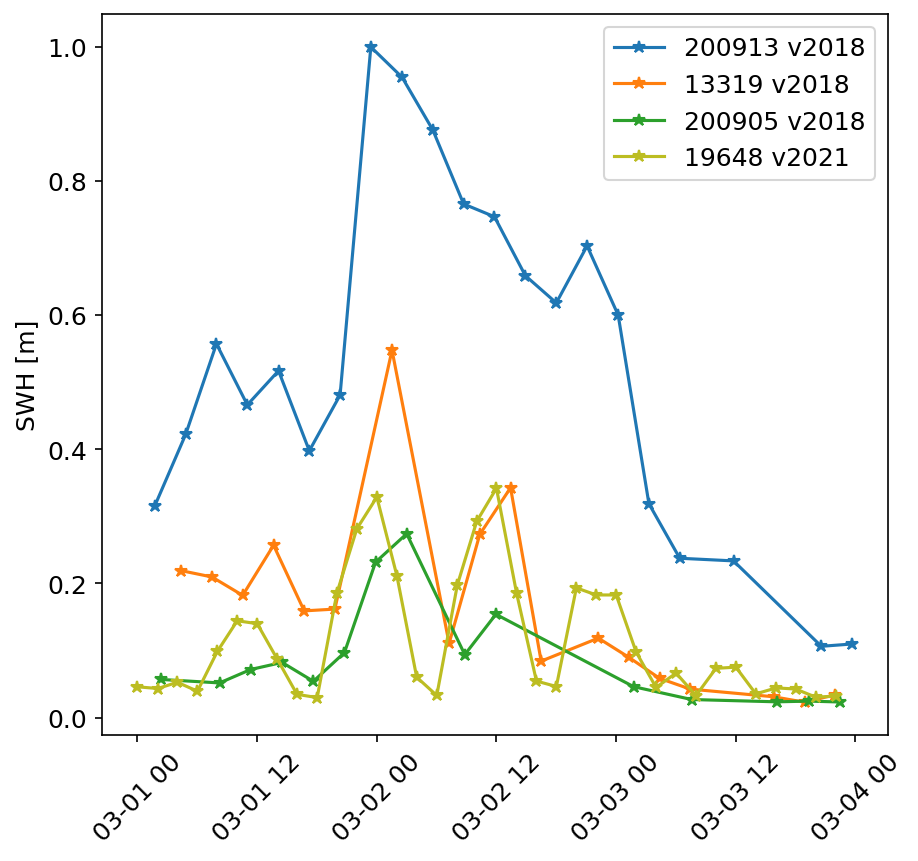

In [17]:
path_to_ice_files = "./../../common_nc_data/"
list_ice_files = [
    path_to_ice_files + "ice_his.an.20210301.nc",
]

####################

# load the convergence / divergence data
# what we are interested in is:
data_ice_files = xr.open_mfdataset(list_ice_files)

####################

# locally, convergence / divergence at the location of the instrument in time vs Hs modulation
# for each instrument, get lat lon, get the closest convergence / divergence

# fill in the data

for crrt_instrument in dict_lists_data_relevant:
    crrt_dict = dict_lists_data_relevant[crrt_instrument]
    crrt_dict["convergence"] = []

    for (crrt_time, crrt_lat, crrt_lon) in zip(crrt_dict["twh"], crrt_dict["lat"], crrt_dict["lon"]):
        # print("")
        # ic(crrt_instrument)
        # ic(crrt_time)
        # ic(crrt_lat)
        # ic(crrt_lon)

        # does not work
        # crrt_convergence = data_ice_files.sel(ULAT=crrt_lat, ULON=crrt_lon, timtime=crrt_time, method="nearest")

        # which time to use
        crrt_nearest_time = data_ice_files.sel(time=crrt_time, method="nearest")

# plot

# plt.subplots(1, 1, figsize=(10, 10))
# plt.subplots(1, 1, figsize=(5, 7))
cm = 1/2.54  # centimeters in inches
plt.figure(dpi=150, figsize=(16*cm, 15*cm))
ax1 = plt.subplot(1, 1, 1)

# plot swh
# for crrt_index, crrt_instrument in enumerate(event_1_list_instruments_neighborhood):
list_custom_colors = [list_colors[0], list_colors[1], list_colors[2], list_colors[8]]
for crrt_index, crrt_instrument in enumerate(["200913", "13319", "200905", "19648"]):
    ax1.plot(
        # dict_lists_data_relevant[crrt_instrument]["twh"], dict_lists_data_relevant[crrt_instrument]["swh"],
        dict_lists_data_all[crrt_instrument]["twh"], dict_lists_data_all[crrt_instrument]["swh"],
        marker="*", linestyle="-", alpha=1.0,
        # color=list_colors[crrt_index],
        color=list_custom_colors[crrt_index],
        label=instrument_label(crrt_instrument)
    )

plt.ylabel("SWH [m]")
plt.xticks(rotation=45)

plt.legend()
plt.tight_layout()

plt.savefig("hs.png")
plt.savefig("hs.pdf")

plt.show()

In [20]:
for crrt_twh, crrt_swh in zip(dict_lists_data_all["19648"]["twh"], dict_lists_data_all["19648"]["swh"]):
    print(f"{crrt_twh}: {crrt_swh}")


2021-03-01 00:00:26: 0.04579666256904602
2021-03-01 02:03:44: 0.04328177869319916
2021-03-01 04:00:42: 0.05256684496998787
2021-03-01 06:01:48: 0.039267633110284805
2021-03-01 08:01:58: 0.0988323986530304
2021-03-01 10:01:10: 0.14427007734775543
2021-03-01 12:01:01: 0.13994526863098145
2021-03-01 14:00:30: 0.08767972886562347
2021-03-01 16:00:36: 0.034599918872117996
2021-03-01 18:01:58: 0.029708845540881157
2021-03-01 20:00:28: 0.18555143475532532
2021-03-01 22:00:27: 0.2813367247581482
2021-03-02 00:00:51: 0.328636109828949
2021-03-02 02:01:05: 0.2117304801940918
2021-03-02 04:00:31: 0.060190897434949875
2021-03-02 06:01:21: 0.03288472443819046
2021-03-02 08:04:55: 0.19751335680484772
2021-03-02 10:01:30: 0.29236629605293274
2021-03-02 12:00:24: 0.34187471866607666
2021-03-02 14:01:22: 0.1855984628200531
2021-03-02 16:00:54: 0.054394178092479706
2021-03-02 18:00:40: 0.046269893646240234
2021-03-02 20:01:06: 0.19330614805221558
2021-03-02 22:00:34: 0.18275758624076843
2021-03-03 00:00

In [ ]:
# for day_sic_delta in range(1, 3):
for day_sic_delta in range(1, 2):

    day_SIC = datetime.timedelta(days=day_sic_delta, hours=6)
    crrt_day = event_1_start + day_SIC
    lon_sic, lat_sic, sic = load_sic(crrt_day, 10)

    plt.subplots(1, 1, figsize=(20, 12))
    ax1 = plt.subplot(1, 1, 1, projection=ccrs.PlateCarree())

    ax1.coastlines('50m')
    ax1.set_extent([16, 29, 75, 81], ccrs.PlateCarree())
    gl = ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                       linewidth=2, color='gray', alpha=0.5, linestyle='--')
    ax1.set_prop_cycle(color=[scalarMap.to_rgba(i) for i in range(NUM_COLORS)])
    pc = plt.pcolormesh(lon_sic, lat_sic, sic, alpha=0.5, linewidth=0, vmin=0, vmax=100, antialiased=True)
    # plt.axis('off')

    cbar = plt.colorbar(orientation="horizontal")
    cbar.set_label('SIC [%]', rotation=0)

    for crrt_index, crrt_instrument in enumerate(event_1_list_instruments_neighborhood):
        # ic(crrt_instrument)
        ax1.plot(
            dict_lists_data[crrt_instrument]["lon"],
            dict_lists_data[crrt_instrument]["lat"],
            marker="*", linestyle="-", alpha=1.0,
            label=instrument_label(crrt_instrument),
            color=list_colors[crrt_index],
        )

        # ic(dict_lists_data[crrt_instrument]["tll"])
        list_timestamps_before = \
            [crrt_timestamp for crrt_timestamp in dict_lists_data[crrt_instrument]["tll"]
                if crrt_timestamp < crrt_day
            ]
        if len(list_timestamps_before) == len(dict_lists_data[crrt_instrument]["tll"]):
            continue
        index = len(list_timestamps_before) - 1
        if index == -1:
            continue
        # ic(index)

        ax1.scatter(
            dict_lists_data[crrt_instrument]["lon"][index],
            dict_lists_data[crrt_instrument]["lat"][index],
            s=100,
            color="black"
        )

    # TODO: show waves this day at the good time!

    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER

    plt.legend()
    plt.title(f"{crrt_day}")
    # plt.savefig(f"./plot_event_1_sic_map_{day_sic_delta}.pdf")
    plt.savefig("old_map.png")
    plt.savefig("old_map.pdf")

In [ ]:
# make the figure big enough
cm = 1/2.54  # centimeters in inches
plt.figure(dpi=150, figsize=(12*cm, 15*cm))
projection = ccrs.NorthPolarStereo()
ax = plt.axes(projection=projection, frameon=True)

crs = ccrs.PlateCarree()

# Draw gridlines in degrees over map
gl = ax.gridlines(crs=crs, draw_labels=True,
                  linewidth=.6, color='gray', alpha=0.5, linestyle='-.', x_inline=False, y_inline=False)
gl.xlabel_style = {"size" : 7}
gl.ylabel_style = {"size" : 7}
# gl.xlocator = mticker.FixedLocator([-45, -30,-15])
gl.ylocator = mticker.FixedLocator([75, 76.5, 78, 79.5, 81, 82.5])
gl.bottom_labels = True
gl.left_labels   = True
gl.top_labels    = True
gl.right_labels  = True
print("init map done")

# To plot borders and coastlines, we can use cartopy feature
ax.add_feature(cf.COASTLINE.with_scale("50m"), lw=0.5)
ax.add_feature(cf.BORDERS.with_scale("50m"), lw=0.3)
# ax.add_feature(cf.OCEAN,facecolor=(0.5,0.5,0.5))
print("add borders and coastline done")

pc = plt.pcolormesh(lon_sic, lat_sic, sic, alpha=0.5, transform=crs, linewidth=0, vmin=0, vmax=100, antialiased=True)
# plt.axis('off')

cbar = plt.colorbar(orientation="horizontal")
cbar.set_label('SIC [%]', rotation=0)

ic(crrt_day)

for crrt_index, crrt_instrument in enumerate(event_1_list_instruments_neighborhood):
    # ic(crrt_instrument)
    plt.plot(
        dict_lists_data[crrt_instrument]["lon"],
        dict_lists_data[crrt_instrument]["lat"],
        transform=crs,
        marker=".", linestyle="-", alpha=1.0,
        label=instrument_label(crrt_instrument),
        color=list_colors[crrt_index],
    )

    # ic(dict_lists_data[crrt_instrument]["tll"])
    list_timestamps_before = \
        [crrt_timestamp for crrt_timestamp in dict_lists_data[crrt_instrument]["tll"]
            if crrt_timestamp < crrt_day
        ]
    if len(list_timestamps_before) == len(dict_lists_data[crrt_instrument]["tll"]):
        continue
    index = len(list_timestamps_before) - 1
    if index == -1:
        continue
    # ic(index)

    plt.scatter(
        dict_lists_data[crrt_instrument]["lon"][index],
        dict_lists_data[crrt_instrument]["lat"][index],
        transform=crs,
        s=100,
        color="black"
    )
    
# plt.legend()

lon_min = 17
lon_max = 29
lat_min = 76
lat_max = 79
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
print("set extent done")

plt.title("")

plt.tight_layout()
print("tight layout done")


plt.savefig("new_map.pdf")
plt.savefig("new_map.png")

plt.show()
print("show done")

In [ ]:
max_duration_between_spectrograms = datetime.timedelta(hours=10)
max_valid_half_duration = datetime.timedelta(hours=5)

time_start_md = mdates.date2num(datetime.datetime(2021, 2, 28, 0, 0, 0))
time_end_md = mdates.date2num(datetime.datetime(2021, 3, 5, 0, 0, 0))

cm = 1/2.54  # centimeters in inches
fig, axes = plt.subplots(nrows=len(list_most_relevant_instruments), ncols=1, dpi=150, figsize=(18*cm, 15*cm))

# one instrument spectrum at a time
for crrt_index, crrt_logger_ID in enumerate(list_most_relevant_instruments):
    plt.subplot(len(list_most_relevant_instruments), 1, crrt_index + 1)

    # get the data to plot
    crrt_datetimes = sorted(list(dict_extracted_data[crrt_logger_ID]["time_wave"].keys()))
    crrt_spectra = [dict_extracted_data[crrt_logger_ID]["time_wave"][crrt_key]["spectrum"] for crrt_key in crrt_datetimes]

    crrt_spectra_logged = np.log10(np.array(crrt_spectra) + 1e-20)

    # add some NaN spectra if too large gaps between consecutive transmissions
    crrt_datetimes_holed = [crrt_datetimes[0]]
    crrt_spectra_logged_holed = [crrt_spectra_logged[0]]

    previous_datetime = crrt_datetimes[0]
    for crrt_datetime_entry, crrt_spectra_logged_entry in zip(crrt_datetimes, crrt_spectra_logged):
        if crrt_datetime_entry - previous_datetime >= max_duration_between_spectrograms:
            crrt_datetimes_holed.append(previous_datetime + max_valid_half_duration)
            crrt_datetimes_holed.append(crrt_datetime_entry - max_valid_half_duration)
            crrt_spectra_logged_holed.append(np.nan * np.ones(np.shape(crrt_spectra_logged_entry)))
            crrt_spectra_logged_holed.append(np.nan * np.ones(np.shape(crrt_spectra_logged_entry)))
        crrt_datetimes_holed.append(crrt_datetime_entry)
        crrt_spectra_logged_holed.append(crrt_spectra_logged_entry)
        previous_datetime = crrt_datetime_entry

    crrt_key = crrt_datetimes[0]
    crrt_frequencies = dict_extracted_data[crrt_logger_ID]["time_wave"][crrt_key]["frequencies"]
    crrt_spectra_logged_holed = np.array(crrt_spectra_logged_holed)

    # we ignore the first spectrum: corrupted by deployment
    pclr = plt.pcolor(crrt_datetimes_holed[1:], crrt_frequencies, np.transpose(crrt_spectra_logged_holed)[:, 1:], vmin=-2.8, vmax=0.2)

    # only set the ticks property once
    if crrt_index < len(list_most_relevant_instruments)-1:
        plt.xticks([])
    plt.xticks(rotation=30)

    # use consistent Y label and X limits
    plt.ylabel("f [Hz]\n(instr. {})".format(crrt_logger_ID))
    plt.xlim([time_start_md, time_end_md])
    plt.ylim([0.05, 0.12])

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
cbar = fig.colorbar(pclr, cax=cbar_ax)
cbar.set_label('log$_{10}$(S) [m$^2$/Hz]')
# plt.tight_layout()
# plt.draw()

fig.savefig("spectra.pdf", dpi=150)
fig.savefig("spectra.png", dpi=150)